# 03. DistilBERT Fine-Tuning Pipeline
## AI Resume–Job Description Semantic Matching System

This notebook walks through fine-tuning `distilbert-base-uncased` on candidate resume and job description pairs for 3-class sequence classification.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import torch

sys.path.insert(0, str(Path.cwd().parent))
from src.config import PROCESSED_DATA_DIR, MODEL_NAME, DISTILBERT_MODEL_DIR
from src.tokenizer import get_tokenizer, explain_tokenization
from src.train import train_distilbert
from src.utils import get_device

print('PyTorch Version:', torch.__version__)
print('Device:', get_device())


PyTorch Version: 2.13.0+cpu
Device: cpu


### 1. Inspect Tokenization with [CLS] and [SEP] Tokens


In [2]:
sample_resume = 'Senior Software Engineer with Python, Docker, and PostgreSQL experience.'
sample_jd = 'Seeking Backend Engineer with Python, Kubernetes, and REST API skills.'

explanation = explain_tokenization(sample_resume, sample_jd)
for k, v in explanation.items():
    print(f'{k}: {v}')


[2026-09-06 12:09:15] [INFO] tokenizer: Loading tokenizer: distilbert-base-uncased


cls_token: [CLS]
cls_token_id: 101
sep_token: [SEP]
sep_token_id: 102
pad_token: [PAD]
pad_token_id: 0
total_tokens: 64
tokens_preview: ['[CLS]', 'senior', 'software', 'engineer', 'with', 'python', ',', 'dock', '##er', ',', 'and', 'post', '##gre', '##s', '##q', '##l', 'experience', '.', '[SEP]', 'seeking']
input_ids_preview: [101, 3026, 4007, 3992, 2007, 18750, 1010, 8946, 2121, 1010, 1998, 2695, 17603, 2015, 4160, 2140, 3325, 1012, 102, 6224]
attention_mask_preview: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### 2. Fine-Tune DistilBERT Model


In [3]:
trainer, history = train_distilbert(
    max_train_samples=300,
    max_val_samples=75,
    max_length=128,
    num_epochs=2,
    batch_size=16,
)

print('\nFine-Tuning Complete!')
print('Validation Macro F1:', history['val_macro_f1_final'])
print('Validation Accuracy:', history['val_accuracy_final'])


[2026-09-06 12:09:22] [INFO] train_distilbert: Using compute device: cpu
[2026-09-06 12:09:22] [INFO] train_distilbert: Subsampling train set to 300 samples (100 per class).
[2026-09-06 12:09:22] [INFO] train_distilbert: Subsampling val set to 75 samples (25 per class).
[2026-09-06 12:09:22] [INFO] train_distilbert: Training on 300 samples, Validating on 75 samples (max_length=128).
[2026-09-06 12:09:22] [INFO] tokenizer: Loading tokenizer: distilbert-base-uncased
[2026-09-06 12:09:24] [INFO] train_distilbert: Initializing pre-trained distilbert-base-uncased for 3-class sequence classification...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[2026-09-06 12:09:25] [INFO] train_distilbert: Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1,Weighted F1
1,1.050518,0.943197,0.666667,0.788197,0.666667,0.558554,0.558554
2,0.830345,0.761651,0.640000,0.696086,0.640000,0.576612,0.576612


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[2026-09-06 12:12:43] [INFO] train_distilbert: Training completed. Global steps: 38, Train Loss: 0.9526
[2026-09-06 12:12:43] [INFO] train_distilbert: Saving fine-tuned model and tokenizer to C:\Users\hp\OneDrive\Desktop\Code\AI Resume–Job Description Semantic Matching System\models\distilbert_resume_matcher


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,Macro F1,Weighted F1
0.830345,0.761651,2,0.640000,0.696086,0.640000,0.576612,0.576612


[2026-09-06 12:12:50] [INFO] train_distilbert: Final Validation Metrics: {'eval_loss': 0.7616511583328247, 'eval_accuracy': 0.64, 'eval_precision': 0.6960864805692392, 'eval_recall': 0.64, 'eval_macro_f1': 0.5766124676743994, 'eval_weighted_f1': 0.5766124676743993}
[2026-09-06 12:12:51] [INFO] train_distilbert: Saved training curves to C:\Users\hp\OneDrive\Desktop\Code\AI Resume–Job Description Semantic Matching System\outputs\figures



Fine-Tuning Complete!
Validation Macro F1: 0.5766124676743994
Validation Accuracy: 0.64


### 3. Training & Validation Loss Curves


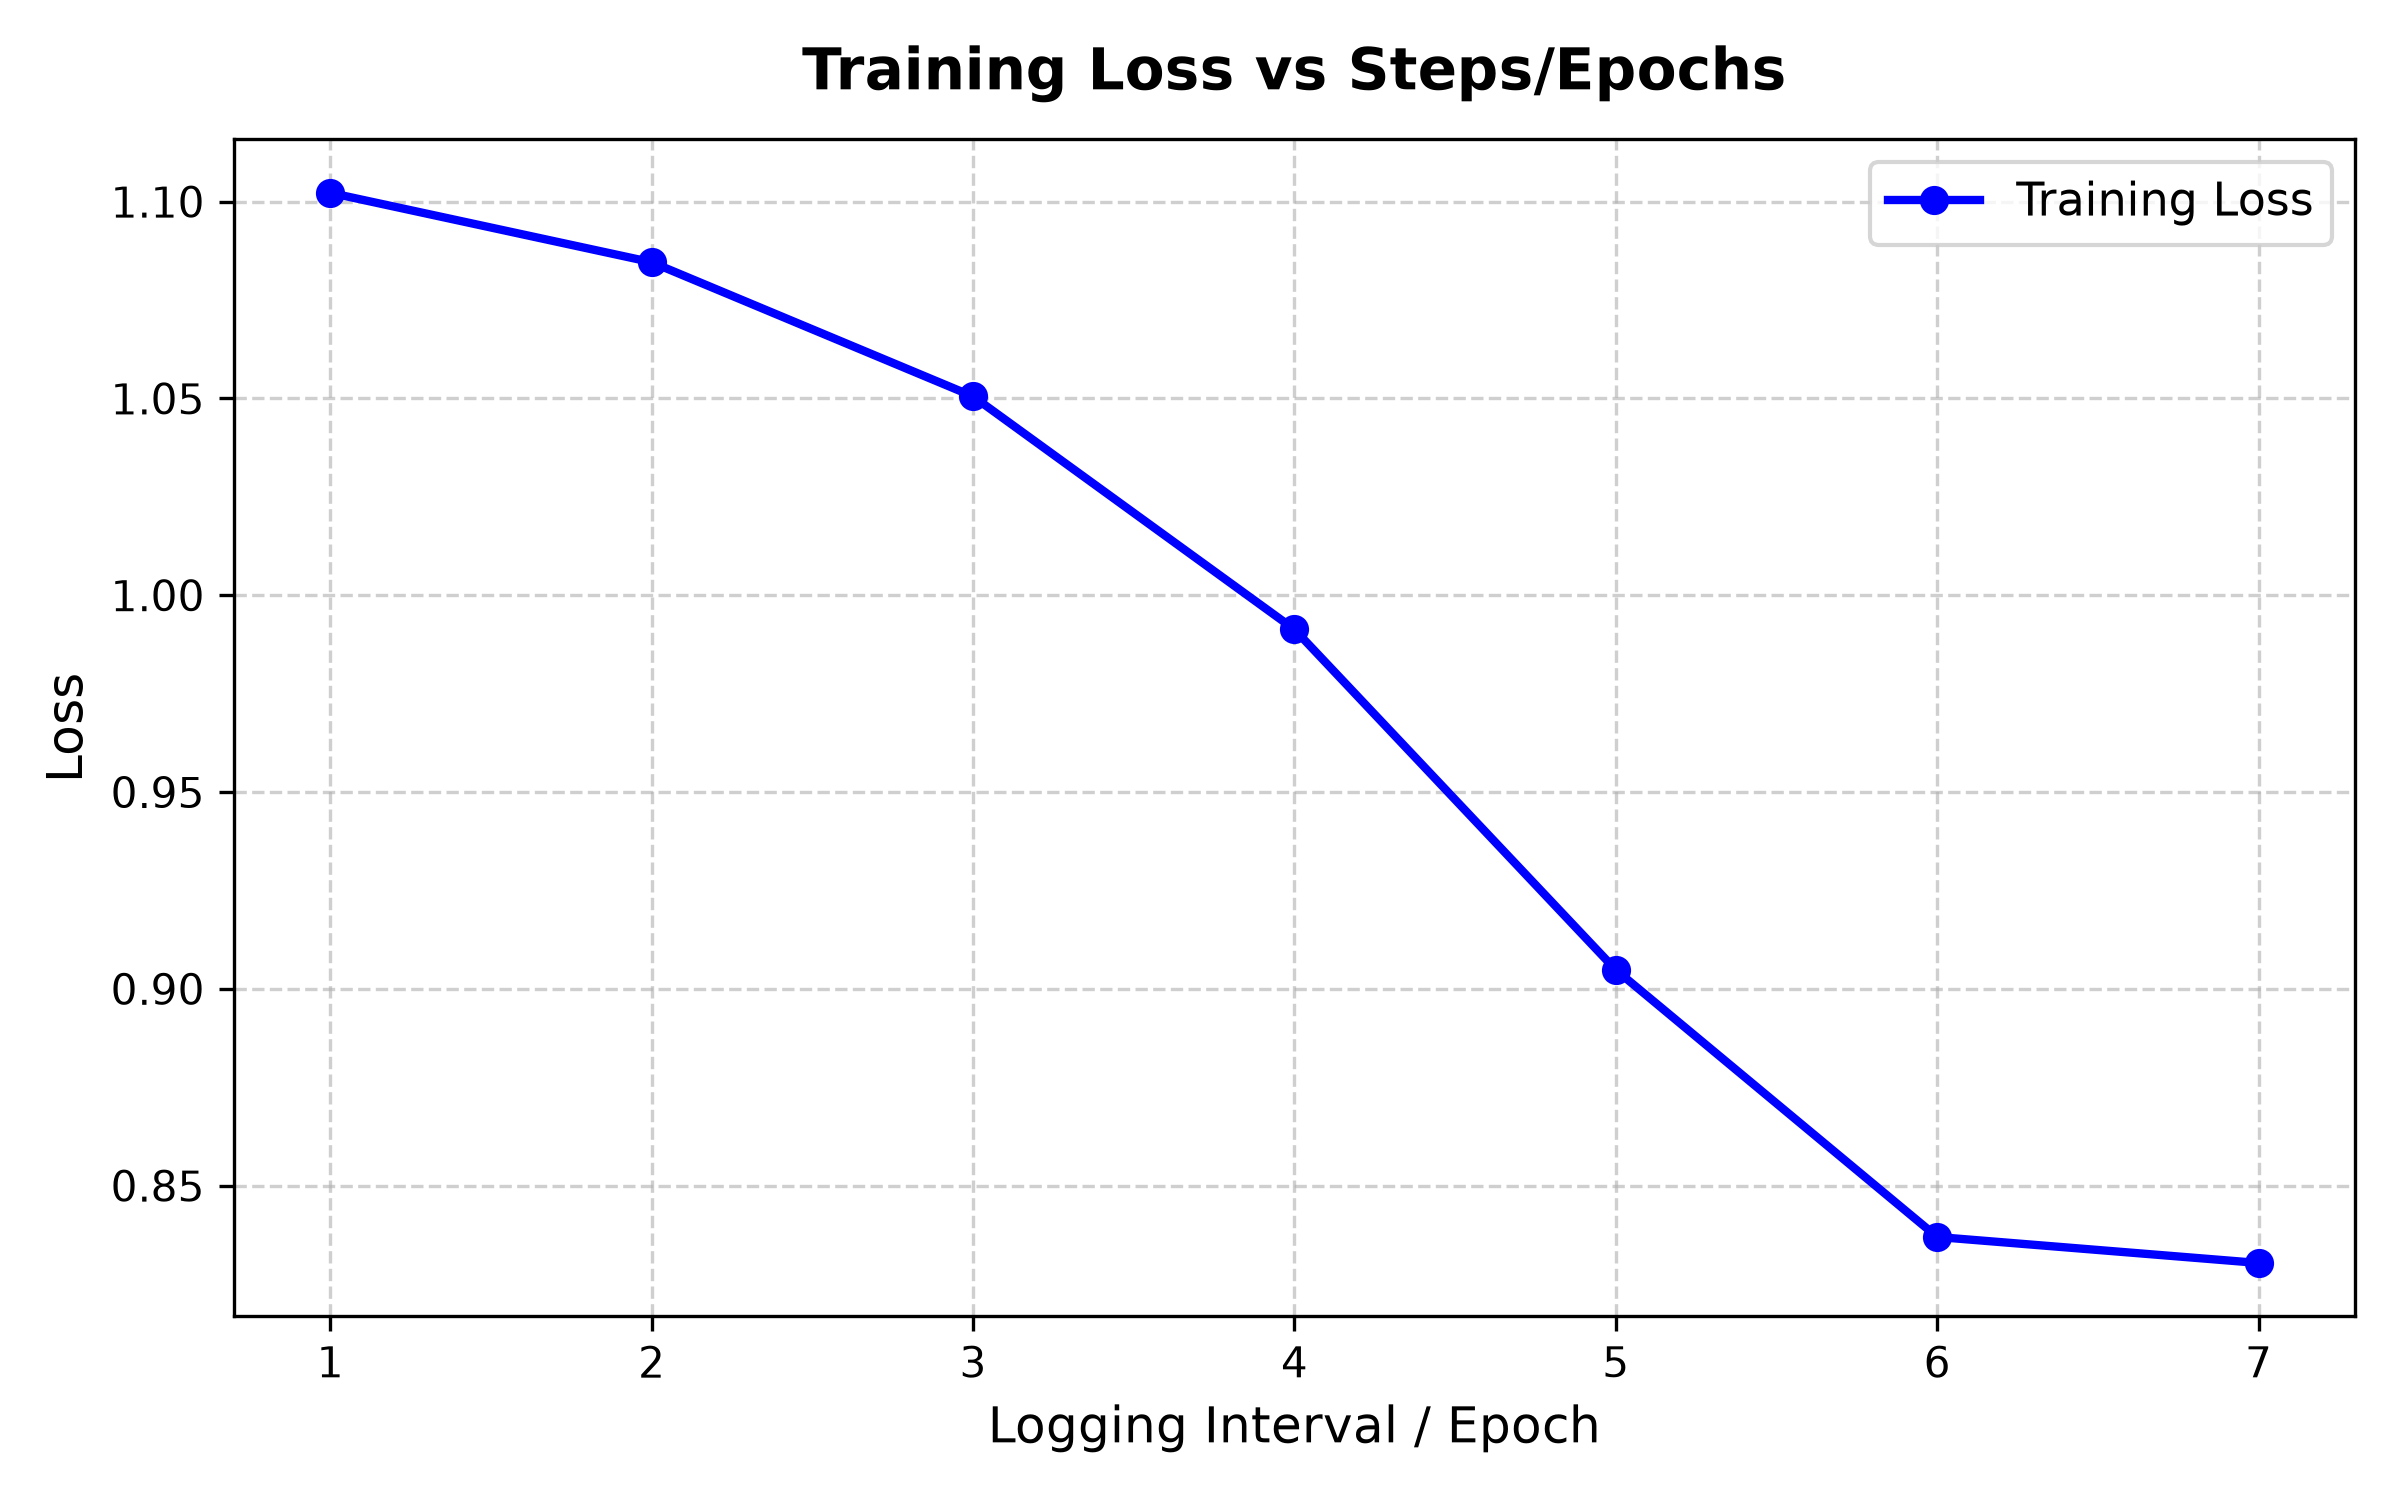

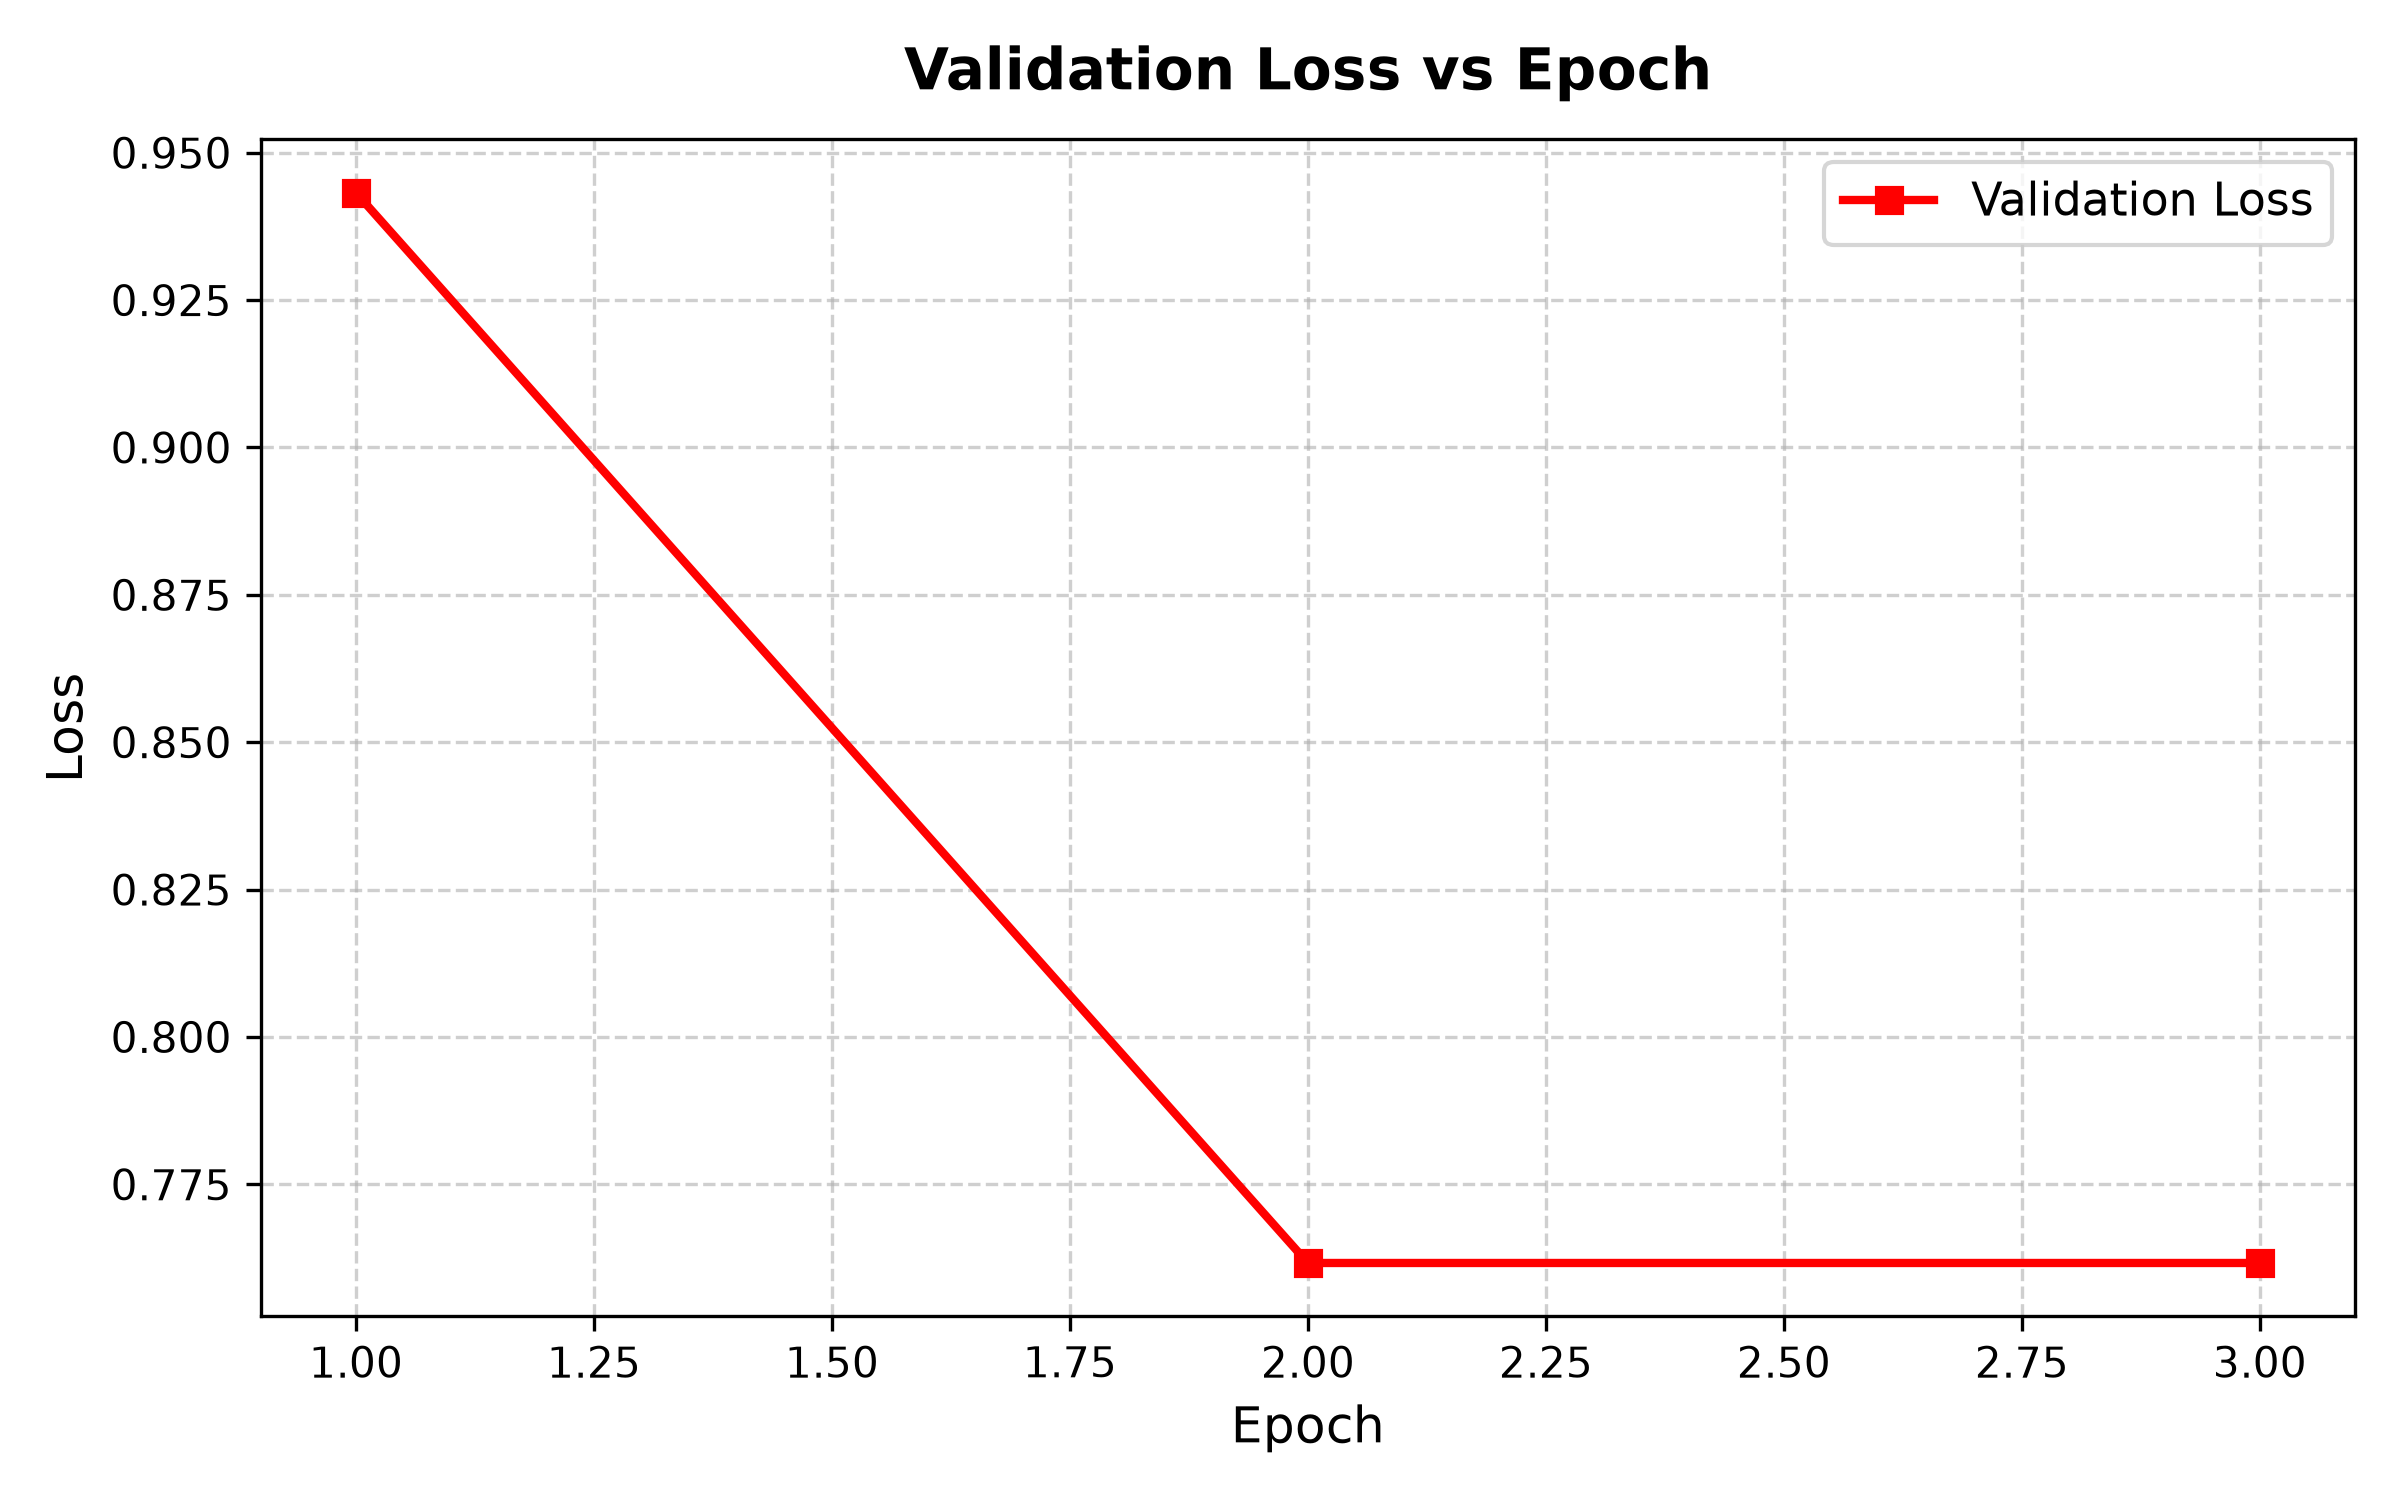

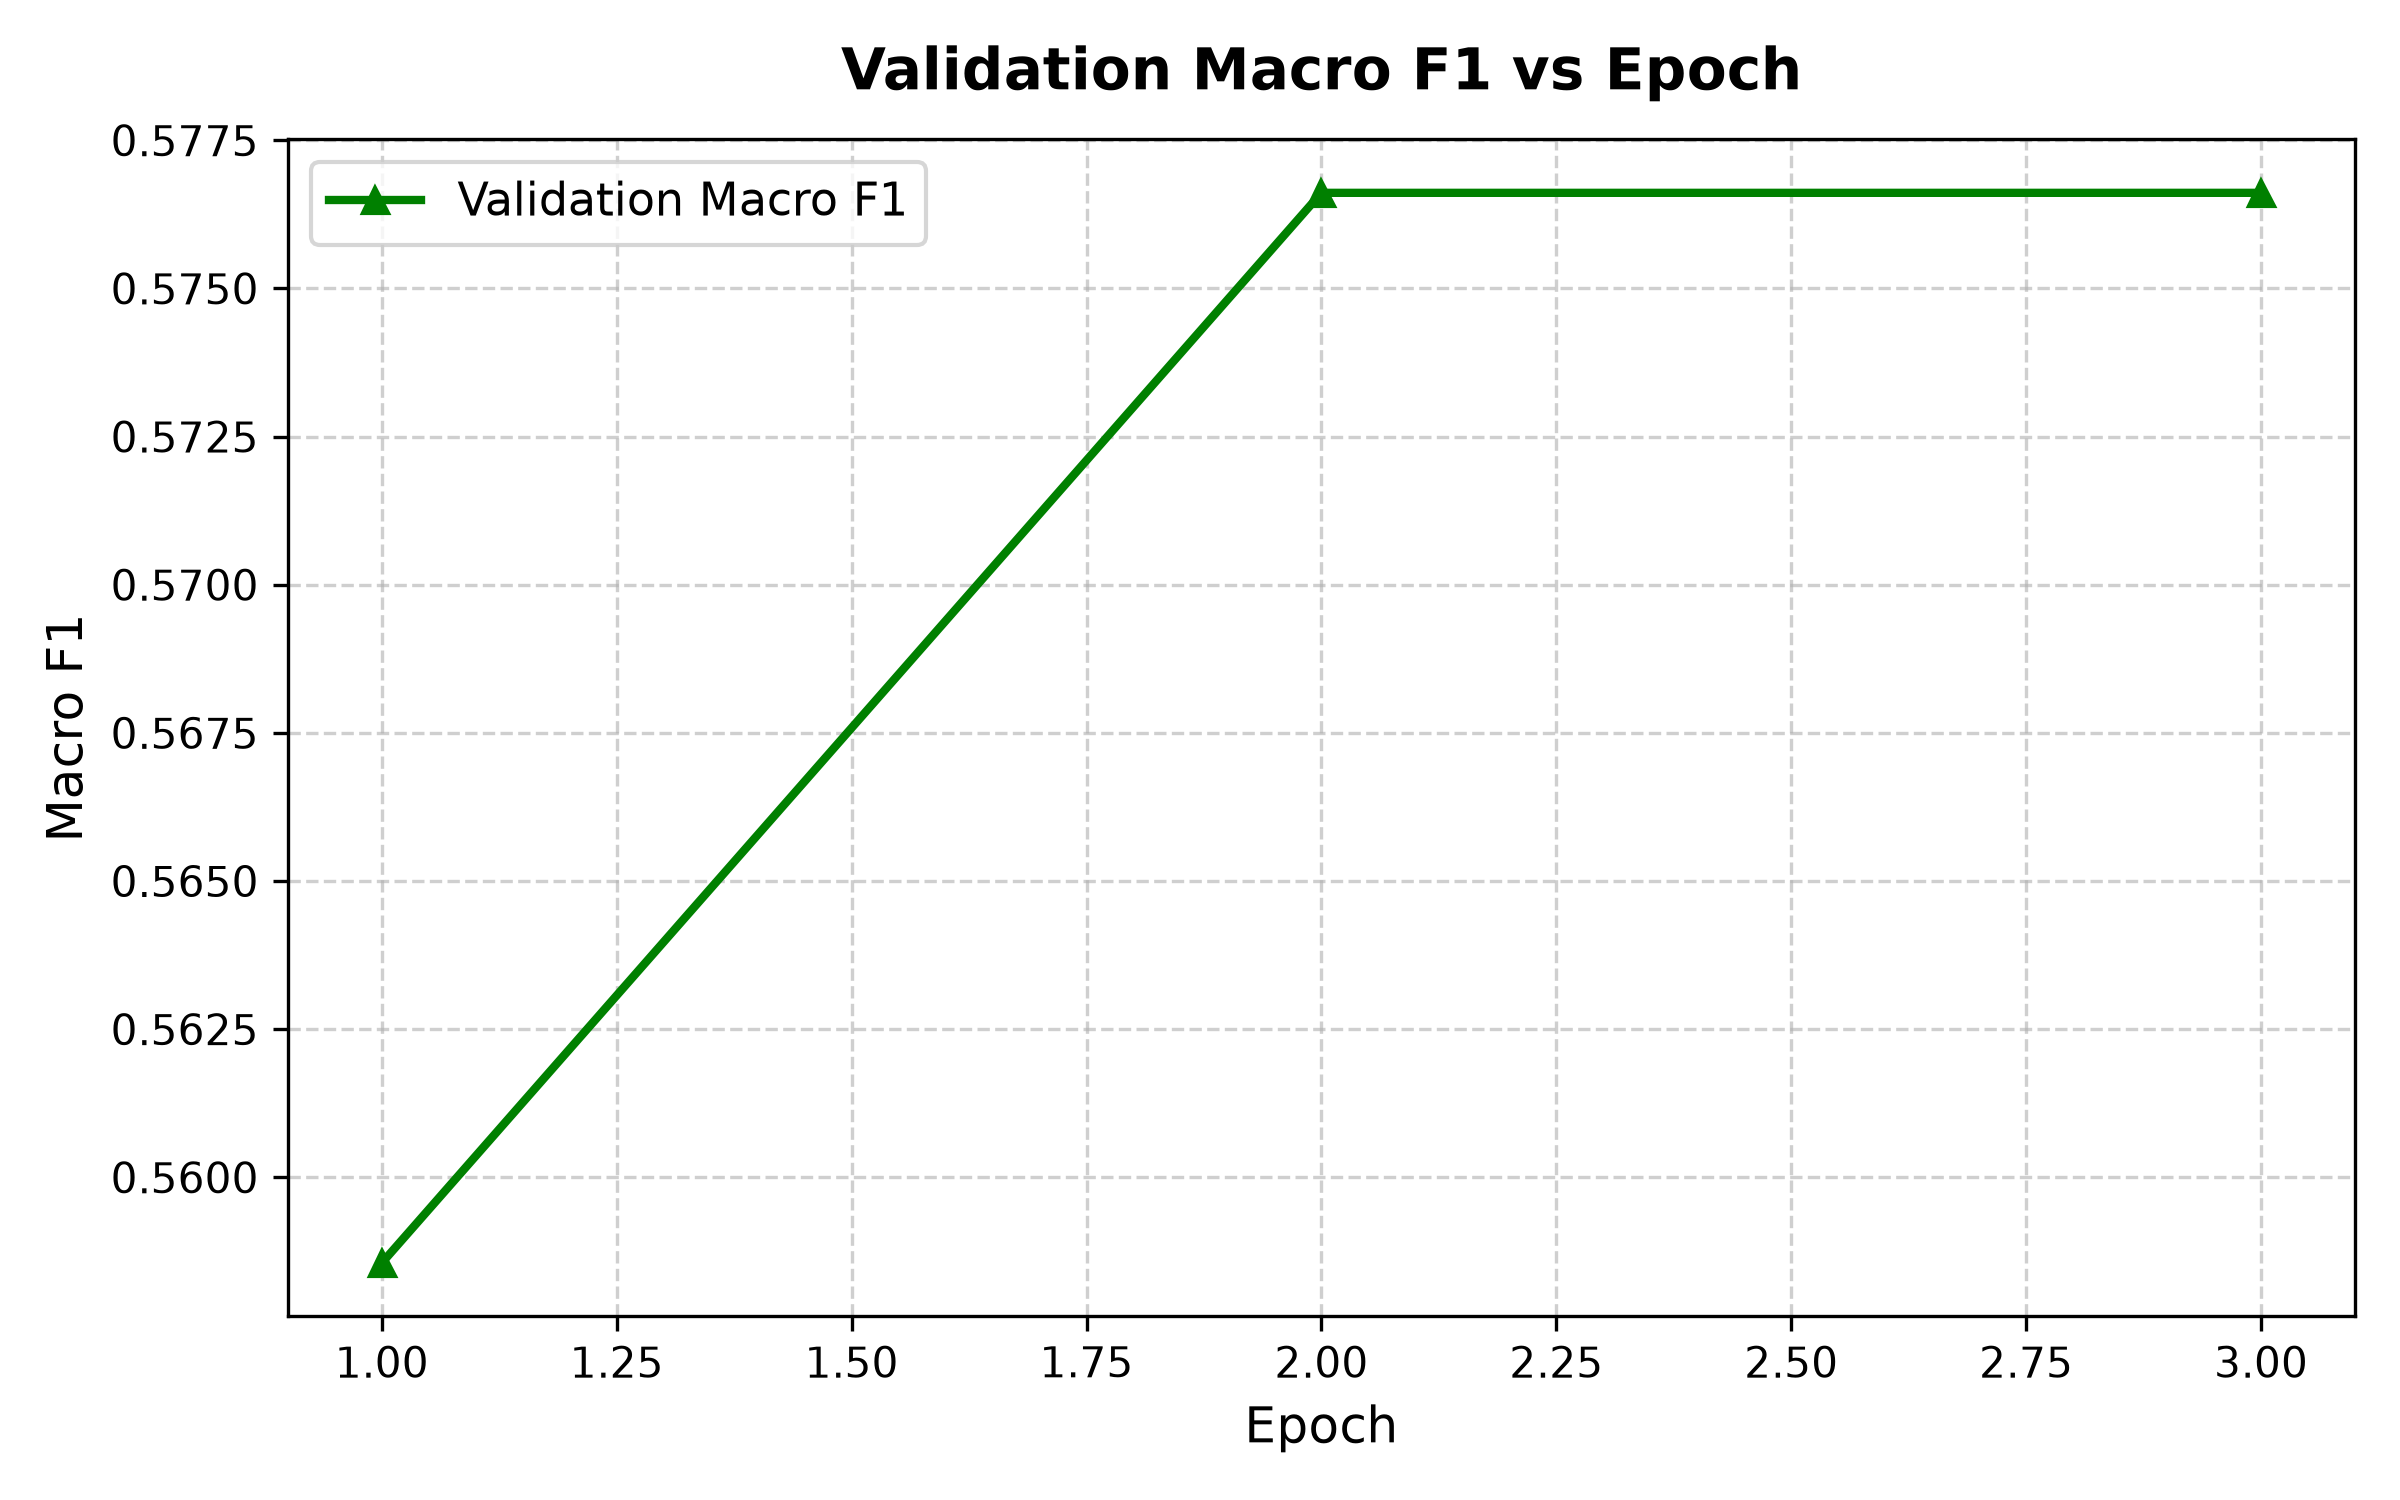

In [4]:
from IPython.display import Image, display
from src.config import FIGURES_DIR

display(Image(filename=str(FIGURES_DIR / 'training_loss.png')))
display(Image(filename=str(FIGURES_DIR / 'validation_loss.png')))
display(Image(filename=str(FIGURES_DIR / 'f1_curve.png')))
